<a href="https://colab.research.google.com/github/SpicyPump/CI345ML/blob/main/Lab8_KNN_MovieStore_unfinished.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# lab 8 - knn classification for Video data



In [44]:
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
video_store_file = '/content/drive/MyDrive/CI345_ML/Data/Video_Store.csv'

original_vtable = pd.read_csv(video_store_file)
original_vtable.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000,25,32,2.5,Action,Yes
1,2,F,54000,33,12,3.4,Drama,No
2,3,F,32000,20,42,1.6,Comedy,No


In [45]:
df = original_vtable
print(df.shape)
print('-------')
print(df.columns)



(50, 8)
-------
Index(['Cust ID', 'Gender', 'Income', 'Age', 'Rentals', 'AvgPerVisit', 'Genre',
       'Like'],
      dtype='object')


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Cust ID      50 non-null     int64  
 1   Gender       50 non-null     object 
 2   Income       50 non-null     int64  
 3   Age          50 non-null     int64  
 4   Rentals      50 non-null     int64  
 5   AvgPerVisit  50 non-null     float64
 6   Genre        50 non-null     object 
 7   Like         50 non-null     object 
dtypes: float64(1), int64(4), object(3)
memory usage: 3.3+ KB


In [47]:
vtable = original_vtable
vtable['Income'] = vtable['Income'].astype(float)
print(vtable.dtypes)
original_vtable.dtypes

Cust ID          int64
Gender          object
Income         float64
Age              int64
Rentals          int64
AvgPerVisit    float64
Genre           object
Like            object
dtype: object


,0
Cust ID,int64
Gender,object
Income,float64
Age,int64
Rentals,int64
AvgPerVisit,float64
Genre,object
Like,object


In [48]:
print(df['Income'].describe())
print(df.Income.describe())
print('------------------------')
#print(df['Income'].describe())


count       50.000000
mean     42300.000000
std      21409.753642
min       1000.000000
25%      26750.000000
50%      41000.000000
75%      56750.000000
max      89000.000000
Name: Income, dtype: float64
count       50.000000
mean     42300.000000
std      21409.753642
min       1000.000000
25%      26750.000000
50%      41000.000000
75%      56750.000000
max      89000.000000
Name: Income, dtype: float64
------------------------


In [49]:
df = original_vtable
df.head(2)

,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000.0,25,32,2.5,Action,Yes
1,2,F,54000.0,33,12,3.4,Drama,No


Genre
Drama     20
Action    18
Comedy    12
Name: count, dtype: int64


<Axes: xlabel='Genre'>

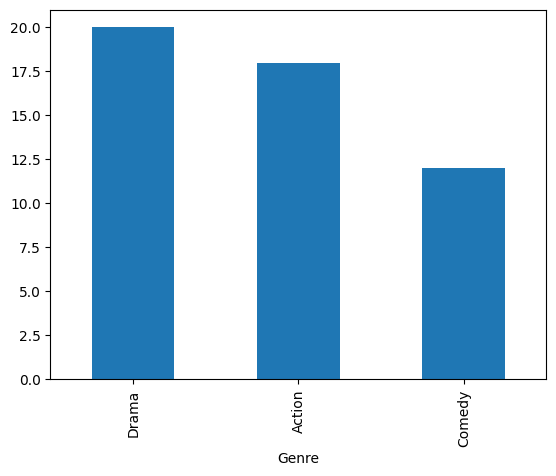

In [50]:
res = df.Genre.value_counts()
print(res)
res.plot(kind = 'bar')

<Axes: title={'center': 'Income'}, ylabel='Frequency'>

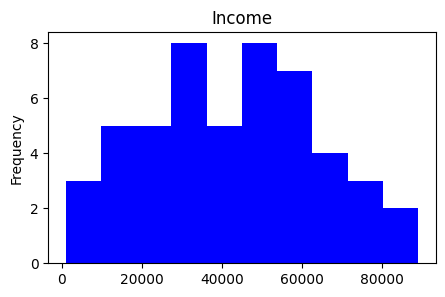

In [51]:
df = original_vtable
res = df["Income"]
res.plot(kind = 'hist', title = 'Income', color = 'blue', figsize = (5,3))

<Axes: title={'center': 'Percentage in Each Genre'}, ylabel='count'>

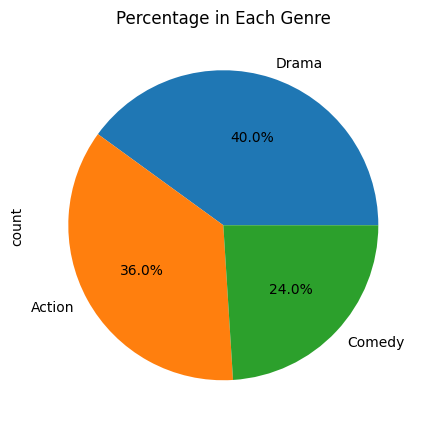

In [52]:
res = df['Genre'].value_counts()
res.plot(
    kind = 'pie', autopct = '%1.1f%%',
    title = 'Percentage in Each Genre',
    figsize = (5, 6)
    )

array([[<Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Rentals'}>,
        <Axes: title={'center': 'AvgPerVisit'}>]], dtype=object)

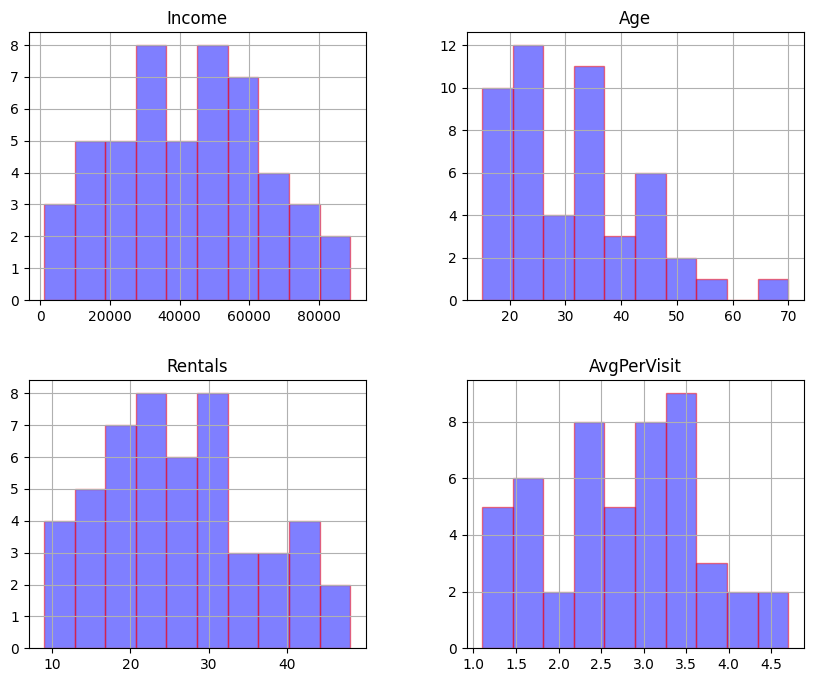

In [53]:
df = original_vtable
res = df[['Income', 'Age', 'Rentals', 'AvgPerVisit']]
res
res.hist(alpha = 0.5, edgecolor = 'red', color = 'blue', figsize = (10,8))

In [54]:
res = df['Like'].value_counts()


In [55]:
#step 3: Data processing
#Convert: categoric feature to numerical feature
# Method 1: using label Encoder

In [56]:
print(df.shape)
df.head(2)

(50, 8)


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000.0,25,32,2.5,Action,Yes
1,2,F,54000.0,33,12,3.4,Drama,No


In [57]:

from sklearn.preprocessing import LabelEncoder
# vs Method
encoder = LabelEncoder()
df = df.apply(encoder.fit_transform)
#print(df.dtypes)
df.head(2)

# There are problems!!!

,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,0,1,19,8,20,10,0,1
1,1,0,24,13,2,18,2,0


In [58]:
# vs Only convert Categorical feautures to Numercial
le = LabelEncoder()
df = original_vtable
df['Gender'] = le.fit_transform(df['Gender'])
df['Genre'] = le.fit_transform(df['Genre'])
df['Like'] = le.fit_transform(df['Like'])
df_use_LabelEncoder = df
print(df.dtypes)
df.head(2)

Cust ID          int64
Gender           int64
Income         float64
Age              int64
Rentals          int64
AvgPerVisit    float64
Genre            int64
Like             int64
dtype: object


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,1,45000.0,25,32,2.5,0,1
1,2,0,54000.0,33,12,3.4,2,0


In [59]:
# Current process data has not category
vtable = df_use_LabelEncoder
# Seperate data part
v_data = vtable[['Gender','Income','Age','Rentals', 'AvgPerVisit','Genre']]
# Get target
v_target = vtable['Like']

print(v_data.shape)
print(v_target.shape)
v_data.head(3)

(50, 6)
(50,)


,Gender,Income,Age,Rentals,AvgPerVisit,Genre
0,1,45000.0,25,32,2.5,0
1,0,54000.0,33,12,3.4,2
2,0,32000.0,20,42,1.6,1


In [60]:
# Step 3: Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (v_data, v_target, random_state = 11, test_size = 0.2)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

# Step 4: Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 3
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

#Training the KNN classifier
knn_classifier.fit (X = data_train, y = target_train)
#print(knn_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)

# Step 6: Evaluation
# Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

(40, 6)
(10, 6)
(40,)
(10,)
KNeighborsClassifier(n_neighbors=3, weights='distance')
              precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.43      1.00      0.60         3

    accuracy                           0.60        10
   macro avg       0.71      0.71      0.60        10
weighted avg       0.83      0.60      0.60        10

------ Confusion Matrix
[[3 4]
 [0 3]]



# Converting categoric feature to numerical feature

## Method 2 : Using get_dummies -

In [71]:
# Data Processomg
# Convert Converting categoric feature to numerical feature

# Method 2 : Using get_dummies


gender_df= pd.get_dummies(df['Gender'])

v_matrix = pd.get_dummies(original_vtable)
print(v_matrix.dtypes)
print(v_matrix.head(2))

v_matrix = v_matrix.astype(int)
print(v_matrix.head(2))

# Problem : numberical features also changed !!!!


Cust ID          int64
Gender           int64
Income         float64
Age              int64
Rentals          int64
AvgPerVisit    float64
Genre            int64
Like             int64
dtype: object
   Cust ID  Gender   Income  Age  Rentals  AvgPerVisit  Genre  Like
0        1       1  45000.0   25       32          2.5      0     1
1        2       0  54000.0   33       12          3.4      2     0
   Cust ID  Gender  Income  Age  Rentals  AvgPerVisit  Genre  Like
0        1       1   45000   25       32            2      0     1
1        2       0   54000   33       12            3      2     0


In [77]:

# Only converting categoric features to numerical feature

# Method 2 : Using get_dummies -

category_cols = ['Gender', 'Genre', 'Like']

df_use_dummies = pd.get_dummies(df, columns = category_cols , dtype=int)
print('-----')
print(df_use_dummies.dtypes)
df_use_dummies.head(2)


-----
Cust ID          int64
Income         float64
Age              int64
Rentals          int64
AvgPerVisit    float64
Gender_0         int64
Gender_1         int64
Genre_0          int64
Genre_1          int64
Genre_2          int64
Like_0           int64
Like_1           int64
dtype: object


,Cust ID,Income,Age,Rentals,AvgPerVisit,Gender_0,Gender_1,Genre_0,Genre_1,Genre_2,Like_0,Like_1
0,1,45000.0,25,32,2.5,0,1,1,0,0,0,1
1,2,54000.0,33,12,3.4,1,0,0,0,1,1,0


In [81]:
# Current process data has not category
vtable = df_use_dummies
# Seperate data part
v_data = vtable [[ 'Income', 'Age','Rentals','AvgPerVisit','Gender_0', 'Genre_0','Genre_1',	'Genre_2']]
# Get target
v_target = vtable['Like_0']

print(v_data.shape)
print(v_target.shape)
v_data.head(3)

(50, 8)
(50,)


,Income,Age,Rentals,AvgPerVisit,Gender_0,Genre_0,Genre_1,Genre_2
0,45000.0,25,32,2.5,0,1,0,0
1,54000.0,33,12,3.4,1,0,0,1
2,32000.0,20,42,1.6,1,0,1,0


In [83]:
# Seperate data and target, after use dummies
# Drop duplicated columns


print(df_use_dummies.shape)
df_use_dummies.head(2)


print(all_cols)

size = len(all_cols)
#print(size)

data_cols =all_cols [0:(size-2)]
#print(data_cols)
#print(df_use_dummies.columns[0:(size-2)] )

# Seperate data part
# v_data = vtable[['Gender','Income','Age','Rentals', 'AvgPerVisit','Genre']]

# Get target


print(v_data.shape)
print(v_target.shape)
v_data.head(2)

(50, 12)


NameError: name 'all_cols' is not defined

# Step 6: KNN Classification Again

In [84]:
# Step 3: Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (v_data, v_target, random_state = 11, test_size = 0.2)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

# Step 4: Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 3
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

#Training the KNN classifier
knn_classifier.fit (X = data_train, y = target_train)
#print(knn_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)

# Step 6: Evaluation
# Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

(40, 8)
(10, 8)
(40,)
(10,)
KNeighborsClassifier(n_neighbors=3, weights='distance')
              precision    recall  f1-score   support

           0       0.43      1.00      0.60         3
           1       1.00      0.43      0.60         7

    accuracy                           0.60        10
   macro avg       0.71      0.71      0.60        10
weighted avg       0.83      0.60      0.60        10

------ Confusion Matrix
[[3 0]
 [4 3]]


In [65]:
v_target.head(2)

,Like
0,1
1,0


In [66]:
data_train.describe()

,Gender,Income,Age,Rentals,AvgPerVisit,Genre
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,0.525000,42075.000000,31.800000,26.725000,2.812500,1.025000
std,0.505736,20391.536077,12.002564,9.771721,0.867708,0.919518
min,0.000000,1000.000000,16.000000,11.000000,1.400000,0.000000
25%,0.000000,25750.000000,23.500000,19.000000,2.200000,0.000000
50%,1.000000,43000.000000,30.000000,25.500000,2.850000,1.000000
75%,1.000000,56000.000000,35.250000,32.250000,3.325000,2.000000
max,1.000000,83000.000000,70.000000,48.000000,4.700000,2.000000


In [85]:
# After using use_dummies

# Step 3: Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (v_data, v_target, random_state = 11, test_size = 0.2)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

# Step 4: Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier
n_neighbors = 3
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

#Training the KNN classifier
knn_classifier.fit (X = data_train, y = target_train)
#print(knn_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)

# Step 6: Evaluation
# Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

(40, 8)
(10, 8)
(40,)
(10,)
KNeighborsClassifier(n_neighbors=3, weights='distance')
              precision    recall  f1-score   support

           0       0.43      1.00      0.60         3
           1       1.00      0.43      0.60         7

    accuracy                           0.60        10
   macro avg       0.71      0.71      0.60        10
weighted avg       0.83      0.60      0.60        10

------ Confusion Matrix
[[3 0]
 [4 3]]


# Convert categoric feature to numerical feature

## Method 3 : Using HotOneEncoder


In [68]:
#use scores method
score = knn_classifier.score(v_test_norm, target_test)
score

NameError: name 'v_test_norm' is not defined

In [69]:
#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print(matrix)

[[3 4]
 [0 3]]


In [ ]:
#Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)